### LSTMs - IMDB reviews <br>

        Recurrent Neural Networks, a kind of model that takes the ordering of inputs into account. This makes it suitable for different applications such as parts-of-speech tagging, music composition, language translation, and the like.

        The LSTM (Long Short-Term Memory): In a nutshell, it computes the state of a current timestep and passes it on to the next timesteps where this state is also updated. The process repeats until the final timestep where the output computation is affected by all previous states. Not only that, it can be configured to be bidirectional so you can get the relationship of later words to earlier ones.

### Load dataset

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds
import keras_nlp

In [2]:
imdb = tfds.load("imdb_reviews", as_supervised=True, data_dir="./Data/", download=True)

In [3]:
train_reviews = imdb['train'].map(lambda review,label: review)
train_labels = imdb['train'].map(lambda review,label: label)

test_reviews = imdb['test'].map(lambda review,label: review)
test_labels = imdb['test'].map(lambda review,label: label)

### Prepare the dataset

In [4]:
subword_tokenizer = keras_nlp.tokenizers.WordPieceTokenizer(vocabulary='./Data/imdb_vocab_subwords.txt')

In [5]:
SHUFFLE_BUFFER_SIZE = 10000
PREFETCH_BUFFER_SIZE = tf.data.AUTOTUNE
BATCH_SIZE = 256
PADDING_TYPE = 'pre'
TRUNC_TYPE = 'post'

In [6]:
def padding_func(sequences):
    '''
    Generate padded sequences from dataset
    '''
    sequences = sequences.ragged_batch(batch_size=sequences.cardinality())
    sequences = sequences.get_single_element()

    print(f"Single element: {sequences}")
    # Pad the sequences
    padded_sequences = tf.keras.utils.pad_sequences(sequences.numpy(), truncating=TRUNC_TYPE, padding=PADDING_TYPE)

    # Convert back to a tf.data.Dataset
    padded_sequences = tf.data.Dataset.from_tensor_slices(padded_sequences)

    return padded_sequences

In [7]:
# Generate integer sequences using the subword tokenizer
train_sequences_subword = train_reviews.map(lambda review: subword_tokenizer.tokenize(review)).apply(padding_func)
test_sequences_subword = test_reviews.map(lambda review: subword_tokenizer.tokenize(review)).apply(padding_func)

# Combine the integer sequence and labels
train_dataset_vectorized = tf.data.Dataset.zip(train_sequences_subword,train_labels)
test_dataset_vectorized = tf.data.Dataset.zip(test_sequences_subword,test_labels)

# Optimize the datasets for training
train_dataset_final = (train_dataset_vectorized
                       .shuffle(SHUFFLE_BUFFER_SIZE)
                       .cache()
                       .prefetch(buffer_size=PREFETCH_BUFFER_SIZE)
                       .batch(BATCH_SIZE)
                       )

test_dataset_final = (test_dataset_vectorized
                      .cache()
                      .prefetch(buffer_size=PREFETCH_BUFFER_SIZE)
                      .batch(BATCH_SIZE)
                      )

Single element: <tf.RaggedTensor [[209, 175, 195, 674, 630, 178, 15, 680, 8, 85, 189, 77, 2000, 170, 192,
  1766, 4426, 203, 700, 42, 1864, 2116, 15, 1961, 185, 255, 328, 13, 182,
  173, 392, 535, 189, 231, 442, 390, 170, 740, 15, 597, 231, 255, 282, 263,
  186, 1680, 6036, 173, 178, 8, 84, 908, 1045, 15, 209, 178, 168, 195, 638,
  4963, 1657, 1422, 3263, 637, 15, 176, 258, 1648, 312, 234, 330, 223, 164,
  36, 1532, 5576, 758, 326, 4207, 174, 234, 415, 231, 3925, 180, 4554, 174,
  15, 3651, 36, 363, 6855, 1985, 2230, 1828, 303, 1931, 7070, 13, 165, 202,
  5417, 14, 298, 2118, 179, 4426, 175, 353, 182, 66, 1648, 1210, 81, 7017,
  170, 66, 178, 172, 175, 5789, 166, 269, 324, 1606, 15, 42, 427, 938, 172,
  219, 185, 266, 199, 173, 13, 3231, 204, 471, 8, 84, 199, 1766, 4426, 8,
  84, 210, 627, 15, 42, 263, 1575, 1169, 320, 171, 15]                     ,
 [42, 188, 241, 819, 167, 1100, 3064, 526, 275, 13, 182, 173, 168, 952, 972,
  167, 66, 2844, 166, 367, 835, 13, 228, 1903, 13, 281, 2952,

### Build and compile the model

In [8]:
# Model Parameters
EMBEDDING_DIM = 64
LSTM_DIM = 64
DENSE_DIM = 64

# Build the model
model = tf.keras.Sequential([
    tf.keras.Input(shape=(None,)),
    tf.keras.layers.Embedding(subword_tokenizer.vocabulary_size(), EMBEDDING_DIM),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(LSTM_DIM)),
    tf.keras.layers.Dense(DENSE_DIM, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Print the model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, None, 64)       │       488,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 563,009 (2.15 MB)

 Trainable params: 563,009 (2.15 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Set the training parameters
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [10]:
NUM_EPOCHS = 10

history = model.fit(train_dataset_final, epochs=NUM_EPOCHS, validation_data=test_dataset_final)

Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 58s 534ms/step - accuracy: 0.6260 - loss: 0.6105 - val_accuracy: 0.8595 - val_loss: 0.3354
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 53s 541ms/step - accuracy: 0.8793 - loss: 0.2972 - val_accuracy: 0.8689 - val_loss: 0.3246
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 52s 530ms/step - accuracy: 0.8732 - loss: 0.3092 - val_accuracy: 0.8499 - val_loss: 0.3781
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 52s 529ms/step - accuracy: 0.9014 - loss: 0.2545 - val_accuracy: 0.8434 - val_loss: 0.4102
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 52s 529ms/step - accuracy: 0.8977 - loss: 0.2606 - val_accuracy: 0.8230 - val_loss: 0.4052
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 82s 532ms/step - accuracy: 0.9249 - loss: 0.2026 - val_accuracy: 0.8405 - val_loss: 0.4242
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 60s 614ms/step - accuracy: 0.9413 - loss: 0.1640 - val_accuracy: 0.8166 - val_loss: 0.4922
Epoch 8/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 52s 531ms/step - accuracy: 0.9386 - loss: 0.1648 - val_accu

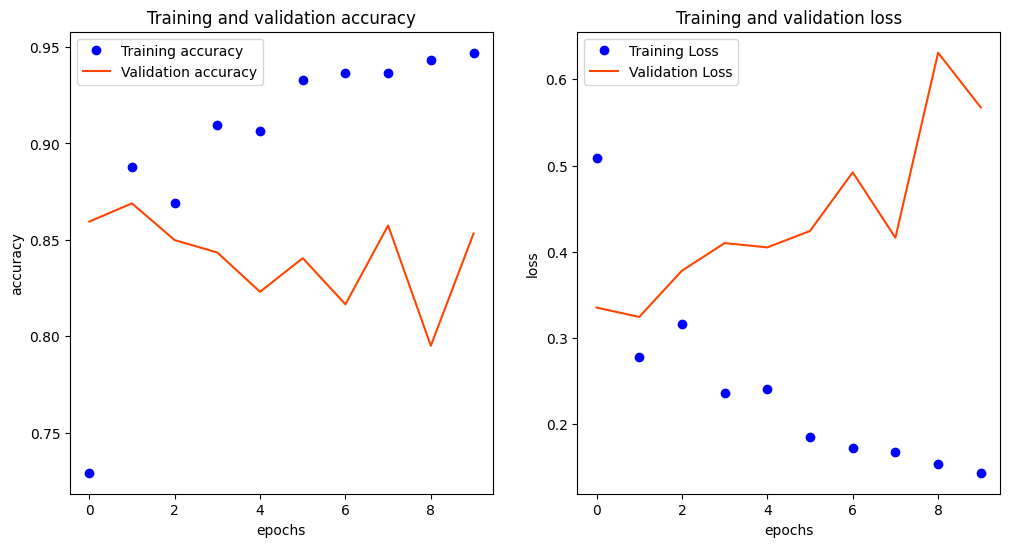

In [31]:
def plot_loss_acc(history):

    '''Plots the training and validation loss and accuracy from a history object'''
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(len(acc))

    fig, ax = plt.subplots(1,2, figsize=(12, 6))
    ax[0].plot(epochs, acc, 'bo', label='Training accuracy')
    ax[0].plot(epochs, val_acc, label='Validation accuracy', color="orangered")
    ax[0].set_title('Training and validation accuracy')
    ax[0].set_xlabel('epochs')
    ax[0].set_ylabel('accuracy')
    ax[0].legend()

    ax[1].plot(epochs, loss, 'bo', label='Training Loss')
    ax[1].plot(epochs, val_loss, label='Validation Loss', color="orangered")
    ax[1].set_title('Training and validation loss')
    ax[1].set_xlabel('epochs')
    ax[1].set_ylabel('loss')
    ax[1].legend()

    plt.show()
plot_loss_acc(history)